In [2]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion
from scipy.ndimage import gaussian_filter 

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
# Recommended for any plot for a science publication.
# Some paper submision systems (e.g. MNRAS) requires next lines to be done for
# your pictures.
# Read more about font types: https://en.wikipedia.org/wiki/PostScript_fonts
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42
# plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight']= 'normal'

source_A = SkyCoord(314.350246, 17.126505, unit="deg")
source_B = SkyCoord(314.348473, 17.128958, unit="deg")
source_C = SkyCoord(314.352254, 17.127635, unit="deg")
source_D = SkyCoord(314.349750, 17.127639, unit="deg")

position_ID1  = SkyCoord(314.350210, 17.126449, unit="deg")
position_ID2  = SkyCoord(314.350342, 17.126498, unit='deg')
position_ID3  = SkyCoord(314.350638, 17.126226, unit='deg')
position_ID4  = SkyCoord(314.351233, 17.127361, unit='deg')
position_ID5  = SkyCoord(314.351263, 17.127169, unit='deg')
position_ID6  = SkyCoord(314.351444, 17.127124, unit='deg')
position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID9  = SkyCoord(314.351688, 17.127728, unit='deg')
position_ID10 = SkyCoord(314.351945, 17.127588, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')
position_ID12 = SkyCoord(314.352156, 17.127821, unit='deg')


Please note the archive will not be available on 6 August at 11:00 CEST during some minutes, for maintenance purposes. Apologies for the inconveniences.


In [3]:
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')
deep_SN3 = cube_SN3.get_deep_frame()
deep_SN3_hdu = fits.open(data_path + 'deep_frame.fits')
wcs = WCS(deep_SN3_hdu[0].header)


cube_SN2 = SpectralCube(data_path + 'SN2.hdf5')
deep_SN2 = cube_SN2.get_deep_frame()
deep_SN2_hdu = fits.open(data_path + 'deep_frame.fits')
wcs = WCS(deep_SN2_hdu[0].header)

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False
unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 113)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


-6839.228440919266 9251.39060555877


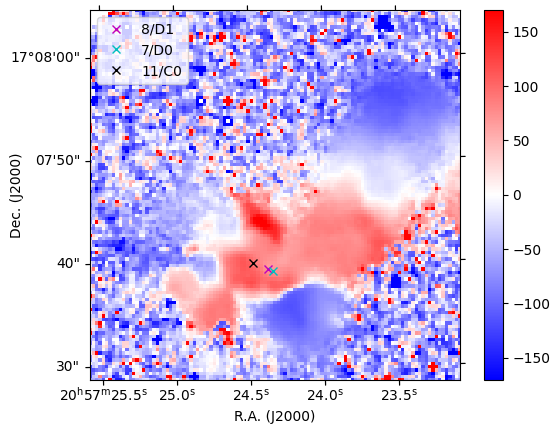

In [9]:


def show_velocity_map(cube_, path_vel, path_flux, path_flux_err,smooth_sigma=0.5):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3

    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    _map = orb.utils.io.read_fits(path_vel).astype(float)
    _map_flux = orb.utils.io.read_fits(path_flux).astype(float)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err).astype(float)



    line_snr = _map_flux / _map_flux_err
    
    # Initial mask
    mask = (line_snr > 3) & np.isfinite(_map)
    
    if smooth_sigma is not None:
        _map = gaussian_filter(_map, sigma=smooth_sigma)

    
  
 
    
    # Apply mask
    _map[~mask] = np.nan

    velocity_map = _map.T - systemic_velocity - sky_velocity_map.T[0].data

    print(np.nanmin(velocity_map), np.nanmax(velocity_map))

    im = ax.imshow(
        velocity_map,
        origin='lower',
        cmap='bwr',
        vmin=-170,
        vmax=170
    )

    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    ax.plot_coord(position_ID11, "x", c='black', label='11/C0')

    ax.legend(loc='upper left')
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)
    fig.colorbar(im, ax=ax)

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_SN3.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
sky_velocity_map = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')
show_velocity_map(cube_SN3, maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits', smooth_sigma=0.5)

In [36]:
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion


redshift = 0.03610
cosmology = cosmo.LambdaCDM(H0=70.0, Om0=0.3, Ode0=0.7)
systemic_velocity = redshift * constants.c * 1e-3
sky_velocity_map = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')

-573.4937491198234 1496.9802804211922


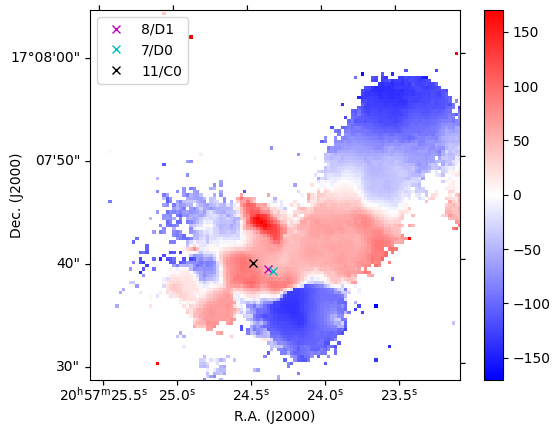

In [25]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='black', label='11/C0')
    ax.legend(loc='upper left')
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.colorbar()
    #plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_SN2.pdf"
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')
show_velocity_map(cube_SN3, maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')

-142.5342202532716 168.3653884442876


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837]
unknown|INFO| Closed glyph list over 'GSUB': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837]
unknown|INFO| Closing glyph list over 'glyf': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837]
unknown|INFO| Closed glyph list over 'glyf': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingre

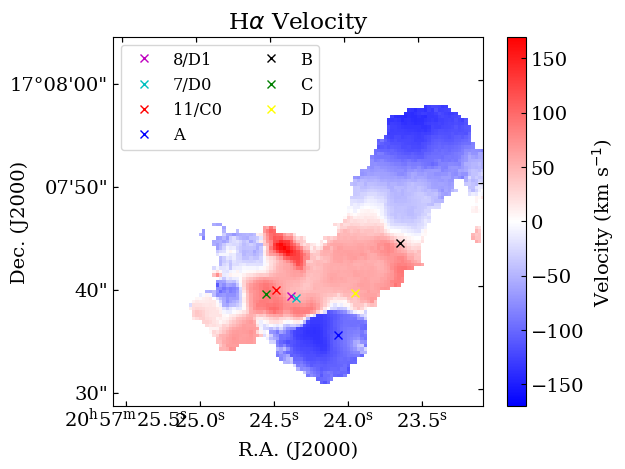

In [54]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err,smooth_sigma=0.2):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    
    if smooth_sigma is not None:
        velocity_map = gaussian_filter(velocity_map, sigma=smooth_sigma)

    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='red', label='11/C0')
    ax.plot_coord(source_A, "x", c='blue', label='A')
    ax.plot_coord(source_B, "x", c='black', label='B')
    ax.plot_coord(source_C, "x", c='green', label='C')
    ax.plot_coord(source_D, "x", c='yellow', label='D')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none' )
    plt.title(r'H$\alpha$ Velocity')
    plt.colorbar(label=r'Velocity (km s$^{-1}$)'
        )
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_ha_vel.pdf")
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')
show_velocity_map(cube_SN3, maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits',smooth_sigma=0.2)

-573.4937491198234 1496.9802804211922


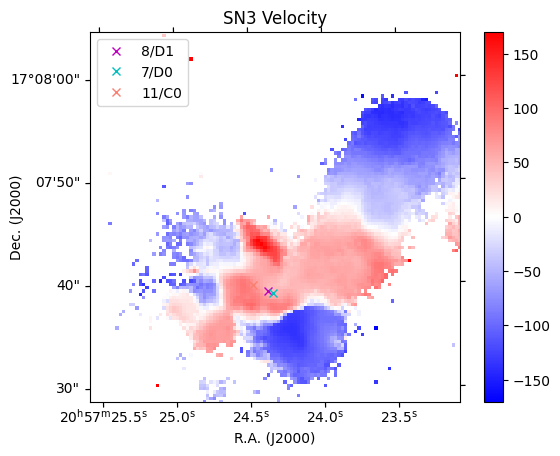

In [28]:
from scipy.ndimage import median_filter
from scipy.ndimage import median_filter
import numpy as np
from scipy.ndimage import label


def show_velocity_map(cube_, path_vel, path_flux, path_flux_err):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    mask = np.isfinite(velocity_map)
    valid = np.isfinite(velocity_map) 
    filled = np.where(valid, velocity_map, np.nanmedian(velocity_map)) 
    smooth = median_filter(filled, size=3) 
    med = median_filter(filled, size=3) 
    resid = np.abs(filled - med) 
    sigma = np.nanstd(filled) 
    velocity_map_clean = np.where((resid > 3*sigma) & valid, med, velocity_map)

    labels, nlabels = label(mask)
    
    # Keep only the largest connected region
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0          # ignore background
    largest = sizes.argmax()
    
    velocity_map_clean = np.where(labels == largest,
                                  velocity_map_clean,
                                  np.nan)
    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    
    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='salmon', label='11/C0')
    ax.legend(loc='upper left')
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.colorbar()
    plt.title('SN3 Velocity')
    plt.show()
    
maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')
show_velocity_map(cube_SN3, maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')

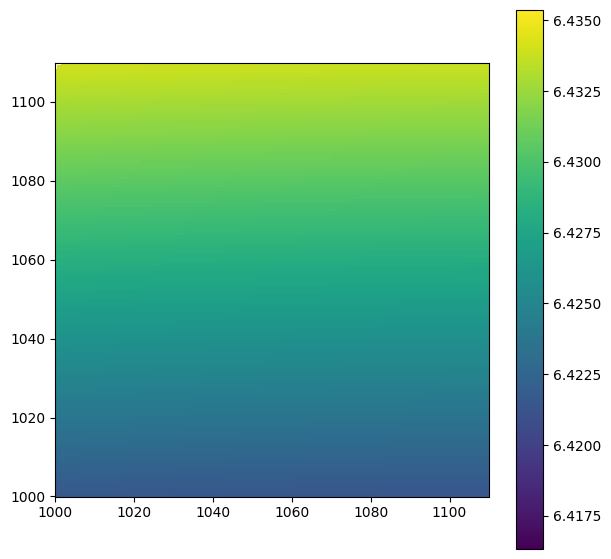

In [29]:
sigma_map = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.fwhm.fits') 
graph.imshow(sigma_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

In [ ]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err,smooth_sigma=0.2):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    
    if smooth_sigma is not None:
        velocity_map = gaussian_filter(velocity_map, sigma=smooth_sigma)

    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "^", c='black', label='11/C0')
    ax.legend(loc='upper left')
    plt.title(r'H$\alpha$ Velocity')
    plt.colorbar(label=r'Velocity (km s$^{-1}$)'
        )
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    #plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_SN2.pdf"
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/IIZw96_SN3/IIZw96_SN3.skymap.fits')
show_velocity_map(cube_SN3, maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits',smooth_sigma=0.2)

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_3440/4007491453.py:13: RuntimeWarning: invalid value encountered in divide
  line_snr = _map_flux / _map_flux_err



-18299.825089909617 1082.7352357129403


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'MATH': 30 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'J', 'R', 'c', 'degree', 'e', 'eight', 'five', 'four', 'h', 'm', 'minus', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'quotedbl', 'quotesingle', 's', 'seven', 'slash', 'space', 'three', 'two', 'zero']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 5, 10, 11, 12, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 36, 38, 39, 45, 53, 70, 72, 75, 80, 86, 114, 2255]
unknown|INFO| Closed glyph list over 'MATH': 36 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'J', 'R', 'c', 'degree', 'e', 'eight', 'five', 'four', 'h', 'm', 'minus', 'nonmarkingretur

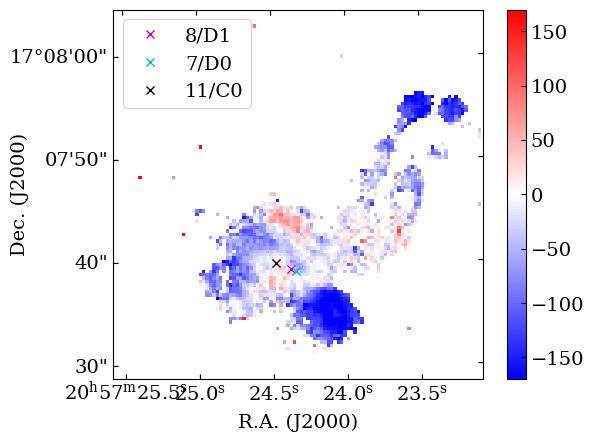

In [43]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='black', label='11/C0')
    ax.legend(loc='upper left')
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.colorbar()
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_SN2.pdf",
            dpi=300, bbox_inches="tight")
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/BFiles/IIZw96_SN2/IIZw96_SN2.skymap.fits')
show_velocity_map(cube_SN2, maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.velocity.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_1008/4004126751.py:13: RuntimeWarning: invalid value encountered in divide
  line_snr = _map_flux / _map_flux_err



-18299.825089909617 1082.7352357129403


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'MATH': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'minus', 'nonmarkingreturn', 'one', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 20, 3228]
unknown|INFO| Closed glyph list over 'MATH': 6 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'minus', 'nonmarkingreturn', 'one', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 20, 3228]
unknown|INFO| Closing glyph list over 'GSUB': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'minus', 'nonmarkingreturn', 'one', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 20, 3228]
unknown|INFO| Closed glyph list over 'GSUB': 6 glyphs after
unknown|INFO| Glyph names: ['.notd

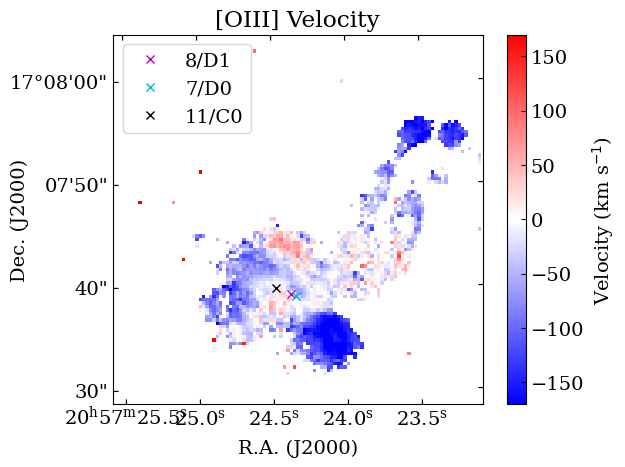

In [11]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err,smooth_sigma=0.1):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    if smooth_sigma is not None:
        velocity_map = gaussian_filter(velocity_map, sigma=smooth_sigma)

    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='black', label='11/C0')
    ax.legend(loc='upper left')
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.title('[OIII] Velocity')
    plt.colorbar(label=r'Velocity (km s$^{-1}$)'
        )
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_OIII.pdf",
            dpi=300, bbox_inches="tight")
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/BFiles/IIZw96_SN2/IIZw96_SN2.skymap.fits')
show_velocity_map(cube_SN2, maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.velocity.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4959.1x1.flux.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4959.1x1.flux-err.fits',smooth_sigma=0.1)

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_1008/984295491.py:13: RuntimeWarning: invalid value encountered in divide
  line_snr = _map_flux / _map_flux_err



-18299.825089909617 1082.7352357129403


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838]
unknown|INFO| Closed glyph list over 'GSUB': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838]
unknown|INFO| Closing glyph list over 'glyf': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838]
unknown|INFO| Closed glyph list over 'glyf': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn

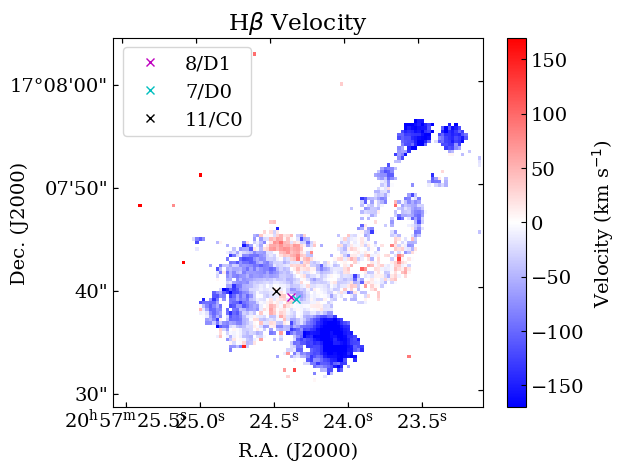

In [10]:
def show_velocity_map(cube_, path_vel, path_flux, path_flux_err,smooth_sigma=0.1):
    redshift = 0.03610
    systemic_velocity = redshift * constants.c * 1e-3
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)
    _map = orb.utils.io.read_fits(path_vel)
    _map_flux = orb.utils.io.read_fits(path_flux)
    _map_flux_err = orb.utils.io.read_fits(path_flux_err)
    line_snr = _map_flux / _map_flux_err
    _map[line_snr<=3] = np.nan
    velocity_map = _map.T - systemic_velocity  - sky_velocity_map[0].data
    print(np.nanmin(velocity_map),np.nanmax(velocity_map))
    if smooth_sigma is not None:
        velocity_map = gaussian_filter(velocity_map, sigma=smooth_sigma)

    plt.imshow(velocity_map, origin='lower', cmap='bwr',
            vmin=-170,
            vmax=170)
    # Region ID8/D1
    ax.plot_coord(position_ID8, "x", c='m', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "x", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "x", c='black', label='11/C0')
    ax.legend(loc='upper left')
    plt.xlim(1000,1110)
    plt.ylim(1000,1110)
    plt.title(r'H$\beta$ Velocity')
    plt.colorbar(label=r'Velocity (km s$^{-1}$)'
        )
    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_velocity_hb.pdf",
            dpi=300, bbox_inches="tight")
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
sky_velocity_map = fits.open('/Users/leianydeoleo/Downloads/BFiles/IIZw96_SN2/IIZw96_SN2.skymap.fits')
show_velocity_map(cube_SN2, maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.velocity.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits', maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits',smooth_sigma=0.1)

In [ ]:
,smooth_sigma=0.2

    if smooth_sigma is not None:
        velocity_map = gaussian_filter(velocity_map, sigma=smooth_sigma)

sigma range (km/s): 1.9169576168060303 197.22604370117188


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837, 855]
unknown|INFO| Closed glyph list over 'GSUB': 6 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837, 855]
unknown|INFO| Closing glyph list over 'glyf': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'alpha', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 837, 855]
unknown|INFO| Closed glyph list over 'glyf': 6 glyphs after
unknown|INFO| Glyph names: [

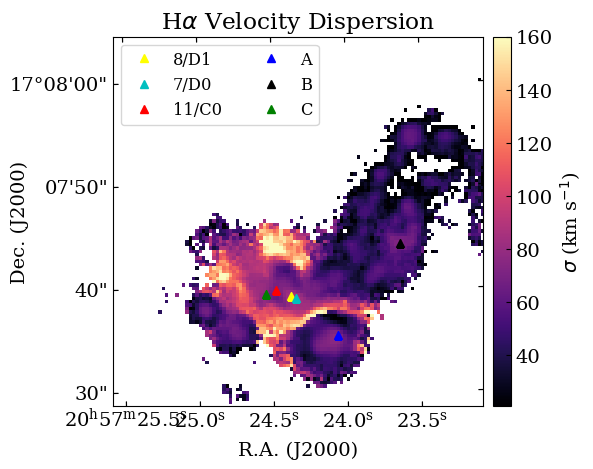

In [53]:
from scipy.ndimage import gaussian_filter  # optional if you want smoothing

def show_sigma_map(cube_, path_sigma, path_flux, path_flux_err,
                   smooth_sigma=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    # Axis formatting
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    # Read maps
    sigma_map = orb.utils.io.read_fits(path_sigma)      # km/s (usually)
    flux_map = orb.utils.io.read_fits(path_flux)
    flux_err_map = orb.utils.io.read_fits(path_flux_err)

    # S/N masking using flux
    line_snr = flux_map / flux_err_map
    sigma_map[line_snr <= 3] = np.nan  # keep only >3σ detections

    # Optional smoothing in pixel space
    if smooth_sigma is not None:
        sigma_map = gaussian_filter(sigma_map, sigma=smooth_sigma)

    # Choose display limits (you can tweak these)
    vmin = np.nanpercentile(sigma_map, 5)
    vmax = np.nanpercentile(sigma_map, 99)
    print("sigma range (km/s):", np.nanmin(sigma_map), np.nanmax(sigma_map))

    im = ax.imshow(
        sigma_map.T,
        origin='lower',
        cmap='magma',      # sequential is better for σ
        vmin=vmin,
        vmax=vmax
    )

    # Region markers
    ax.plot_coord(position_ID8, "^", c='yellow', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "^", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "^", c='red', label='11/C0')
    ax.plot_coord(source_A, "^", c='blue', label='A')
    ax.plot_coord(source_B, "^", c='black', label='B')
    ax.plot_coord(source_C, "^", c='green', label='C')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none')
    plt.title(r'H$\alpha$ Velocity Dispersion')

    # Zoom (same as your other maps)
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\sigma$ (km s$^{-1}$)")

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_broadening_ha.pdf"),
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
show_sigma_map(
    cube_SN3,
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits',      # example name
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits',
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits',
)



sigma range (km/s): 3.138436794281006 189.0760498046875


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'GSUB': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closing glyph list over 'glyf': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'glyf': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 's

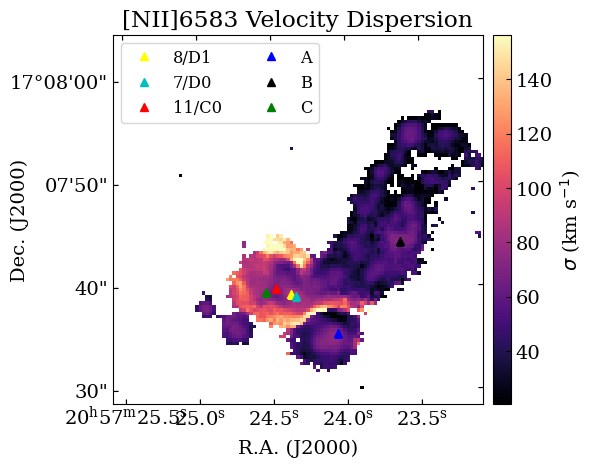

In [56]:
from scipy.ndimage import gaussian_filter  # optional if you want smoothing

def show_sigma_map(cube_, path_sigma, path_flux, path_flux_err,
                   smooth_sigma=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    # Axis formatting
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    # Read maps
    sigma_map = orb.utils.io.read_fits(path_sigma)      # km/s (usually)
    flux_map = orb.utils.io.read_fits(path_flux)
    flux_err_map = orb.utils.io.read_fits(path_flux_err)

    # S/N masking using flux
    line_snr = flux_map / flux_err_map
    sigma_map[line_snr <= 3] = np.nan  # keep only >3σ detections

    # Optional smoothing in pixel space
    if smooth_sigma is not None:
        sigma_map = gaussian_filter(sigma_map, sigma=smooth_sigma)

    # Choose display limits (you can tweak these)
    vmin = np.nanpercentile(sigma_map, 5)
    vmax = np.nanpercentile(sigma_map, 99)
    print("sigma range (km/s):", np.nanmin(sigma_map), np.nanmax(sigma_map))

    im = ax.imshow(
        sigma_map.T,
        origin='lower',
        cmap='magma',      # sequential is better for σ
        vmin=vmin,
        vmax=vmax
    )

    # Region markers
    ax.plot_coord(position_ID8, "^", c='yellow', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "^", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "^", c='red', label='11/C0')
    ax.plot_coord(source_A, "^", c='blue', label='A')
    ax.plot_coord(source_B, "^", c='black', label='B')
    ax.plot_coord(source_C, "^", c='green', label='C')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none')
    plt.title('[NII]6583 Velocity Dispersion')

    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\sigma$ (km s$^{-1}$)")

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_broadening_NII6583.pdf"),
    plt.show()

maps_path_SN3 = '/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN3/MAPS/'
show_sigma_map(
    cube_SN3,
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits',      # example name
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits',
    maps_path_SN3 + 'IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits',
)



unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_1008/2221977666.py:20: RuntimeWarning: invalid value encountered in divide
  line_snr = flux_map / flux_err_map



sigma range (km/s): 7.09830601408612e-07 6825.30908203125


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'GSUB': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closing glyph list over 'glyf': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'glyf': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 's

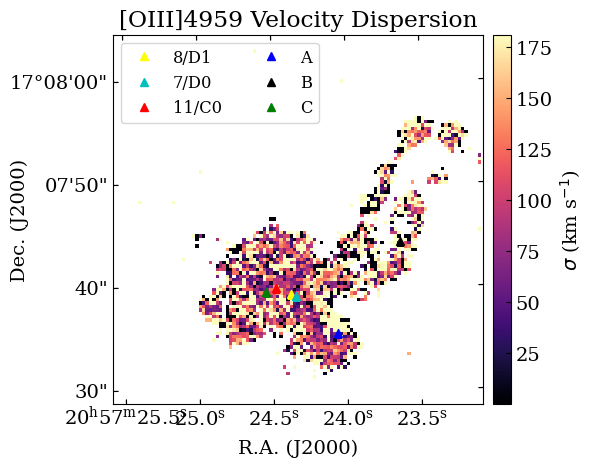

In [62]:
from scipy.ndimage import gaussian_filter  # optional if you want smoothing

def show_sigma_map(cube_, path_sigma, path_flux, path_flux_err,
                   smooth_sigma=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    # Axis formatting
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    # Read maps
    sigma_map = orb.utils.io.read_fits(path_sigma)      # km/s (usually)
    flux_map = orb.utils.io.read_fits(path_flux)
    flux_err_map = orb.utils.io.read_fits(path_flux_err)

    # S/N masking using flux
    line_snr = flux_map / flux_err_map
    sigma_map[line_snr <= 3] = np.nan  # keep only >3σ detections

    # Optional smoothing in pixel space
    if smooth_sigma is not None:
        sigma_map = gaussian_filter(sigma_map, sigma=smooth_sigma)

    # Choose display limits (you can tweak these)
    vmin = np.nanpercentile(sigma_map, 0)
    vmax = np.nanpercentile(sigma_map, 70)
    print("sigma range (km/s):", np.nanmin(sigma_map), np.nanmax(sigma_map))

    im = ax.imshow(
        sigma_map.T,
        origin='lower',
        cmap='magma',      # sequential is better for σ
        vmin=vmin,
        vmax=vmax
    )

    # Region markers
    # Region markers
    ax.plot_coord(position_ID8, "^", c='yellow', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "^", c='c', label='7/D0')
    # Region ID11/C0
    ax.plot_coord(position_ID11, "^", c='red', label='11/C0')
    ax.plot_coord(source_A, "^", c='blue', label='A')
    ax.plot_coord(source_B, "^", c='black', label='B')
    ax.plot_coord(source_C, "^", c='green', label='C')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none')
    plt.title('[OIII]4959 Velocity Dispersion')

    # Zoom (same as your other maps)
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\sigma$ (km s$^{-1}$)")

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_broadening_[OIII]4959.pdf"),
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
show_sigma_map(
    cube_SN2,
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.sigma.fits',      # example name
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4959.1x1.flux.fits',
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4959.1x1.flux-err.fits',
    #smooth_sigma=0.2
)



unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_1008/1562979937.py:20: RuntimeWarning: invalid value encountered in divide
  line_snr = flux_map / flux_err_map



sigma range (km/s): 7.09830601408612e-07 6825.30908203125


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'GSUB': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closing glyph list over 'glyf': 5 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 855]
unknown|INFO| Closed glyph list over 'glyf': 5 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 's

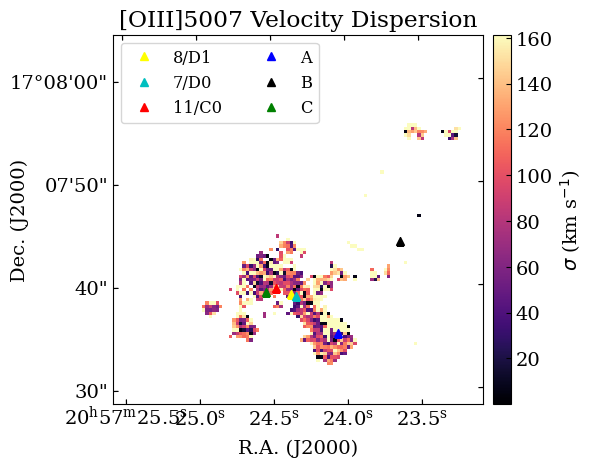

In [64]:
from scipy.ndimage import gaussian_filter  # optional if you want smoothing

def show_sigma_map(cube_, path_sigma, path_flux, path_flux_err,
                   smooth_sigma=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    # Axis formatting
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    # Read maps
    sigma_map = orb.utils.io.read_fits(path_sigma)      # km/s (usually)
    flux_map = orb.utils.io.read_fits(path_flux)
    flux_err_map = orb.utils.io.read_fits(path_flux_err)

    # S/N masking using flux
    line_snr = flux_map / flux_err_map
    sigma_map[line_snr <= 3] = np.nan  # keep only >3σ detections

    # Optional smoothing in pixel space
    if smooth_sigma is not None:
        sigma_map = gaussian_filter(sigma_map, sigma=smooth_sigma)

    # Choose display limits (you can tweak these)
    vmin = np.nanpercentile(sigma_map, 0)
    vmax = np.nanpercentile(sigma_map, 60)
    print("sigma range (km/s):", np.nanmin(sigma_map), np.nanmax(sigma_map))

    im = ax.imshow(
        sigma_map.T,
        origin='lower',
        cmap='magma',      # sequential is better for σ
        vmin=vmin,
        vmax=vmax
    )

    # Region markers
    ax.plot_coord(position_ID8, "^", c='yellow', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "^", c='c', label='7/D0')

    ax.plot_coord(position_ID11, "^", c='red', label='11/C0')
    ax.plot_coord(source_A, "^", c='blue', label='A')
    ax.plot_coord(source_B, "^", c='black', label='B')
    ax.plot_coord(source_C, "^", c='green', label='C')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none')
    plt.title('[OIII]5007 Velocity Dispersion')


    
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\sigma$ (km s$^{-1}$)")

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_broadening_[OIII]5007.pdf"),
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
show_sigma_map(
    cube_SN2,
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.sigma.fits',      # example name
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.5007.1x1.flux.fits',
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits',
    #smooth_sigma=0.2
)



unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_1008/24027425.py:20: RuntimeWarning: invalid value encountered in divide
  line_snr = flux_map / flux_err_map



sigma range (km/s): 7.09830601408612e-07 6825.30908203125


unknown|INFO| maxp pruned
unknown|INFO| cmap pruned
unknown|INFO| kern dropped
unknown|INFO| post pruned
unknown|INFO| FFTM dropped
unknown|INFO| GPOS pruned
unknown|INFO| GSUB pruned
unknown|INFO| glyf pruned
unknown|INFO| Added gid0 to subset
unknown|INFO| Added first four glyphs to subset
unknown|INFO| Closing glyph list over 'GSUB': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838, 855]
unknown|INFO| Closed glyph list over 'GSUB': 6 glyphs after
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838, 855]
unknown|INFO| Closing glyph list over 'glyf': 6 glyphs before
unknown|INFO| Glyph names: ['.notdef', '.null', 'beta', 'nonmarkingreturn', 'sigma', 'space']
unknown|INFO| Glyph IDs:   [0, 1, 2, 3, 838, 855]
unknown|INFO| Closed glyph list over 'glyf': 6 glyphs after
unknown|INFO| Glyph names: ['.n

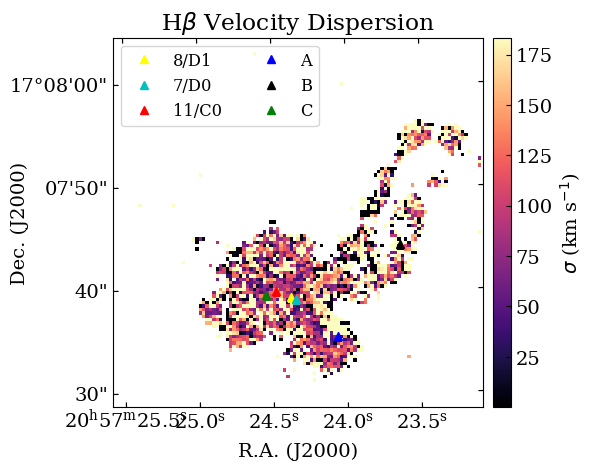

In [69]:
from scipy.ndimage import gaussian_filter  # optional if you want smoothing

def show_sigma_map(cube_, path_sigma, path_flux, path_flux_err,
                   smooth_sigma=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection=cube_.get_wcs())

    # Axis formatting
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_axislabel('R.A. (J2000)')
    ax.coords[1].set_axislabel('Dec. (J2000)', minpad=-0.5)

    # Read maps
    sigma_map = orb.utils.io.read_fits(path_sigma)      # km/s (usually)
    flux_map = orb.utils.io.read_fits(path_flux)
    flux_err_map = orb.utils.io.read_fits(path_flux_err)

    # S/N masking using flux
    line_snr = flux_map / flux_err_map
    sigma_map[line_snr <= 3] = np.nan  # keep only >3σ detections

    # Optional smoothing in pixel space
    if smooth_sigma is not None:
        sigma_map = gaussian_filter(sigma_map, sigma=smooth_sigma)

    # Choose display limits (you can tweak these)
    vmin = np.nanpercentile(sigma_map, 0)
    vmax = np.nanpercentile(sigma_map, 35)
    print("sigma range (km/s):", np.nanmin(sigma_map), np.nanmax(sigma_map))

    im = ax.imshow(
        sigma_map.T,
        origin='lower',
        cmap='magma',      # sequential is better for σ
        vmin=vmin,
        vmax=vmax
    )

   # Region markers
    ax.plot_coord(position_ID8, "^", c='yellow', label='8/D1')
    # Region ID7/D0
    ax.plot_coord(position_ID7, "^", c='c', label='7/D0')

    ax.plot_coord(position_ID11, "^", c='red', label='11/C0')
    ax.plot_coord(source_A, "^", c='blue', label='A')
    ax.plot_coord(source_B, "^", c='black', label='B')
    ax.plot_coord(source_C, "^", c='green', label='C')
    ax.legend(loc='upper left',fontsize='small', ncol=2, facecolor= 'none')
    plt.title(r'H$\beta$ Velocity Dispersion')

    # Zoom (same as your other maps)
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\sigma$ (km s$^{-1}$)")

    plt.savefig("/Users/leianydeoleo/Desktop/IIZw96_broadening_hb.pdf"),
    plt.show()

maps_path_SN2 = '/Users/leianydeoleo/Desktop/IIZw96/MAPS(SN2)/'
show_sigma_map(
    cube_SN2,
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.all.1x1.sigma.fits',      # example name
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits',
    maps_path_SN2 + 'IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits',
    #smooth_sigma=0.2
)

